PPP (with BM3D) Image Demosaicing
=================================

This example demonstrates the use of the ADMM Plug and Play Priors (PPP)
algorithm <cite data-cite="venkatakrishnan-2013-plugandplay2"/>, with the BM3D
<cite data-cite="dabov-2008-image"/> denoiser, for solving a raw image demosaicing
problem.

In [1]:
import numpy as np

from bm3d import bm3d_rgb

# Workarounds for colour_demosaicing incompatibility with NumPy 2.x
np.float_ = np.float64
np.float = np.float64
np.complex = np.complex128
np.sctypes = {
    "float": [np.float16, np.float32, np.float64, np.longdouble],
    "int": [np.int8, np.int16, np.int32, np.int64],
}
import komplot as kplt
from colour_demosaicing import demosaicing_CFA_Bayer_Menon2007

import scico
import scico.numpy as snp
import scico.random
from scico import functional, linop, loss, metric
from scico.data import kodim23
from scico.optimize.admm import ADMM, LinearSubproblemSolver
from scico.util import device_info

Read a ground truth image.

In [2]:
img = snp.array(kodim23(asfloat=True)[160:416, 60:316])

Define demosaicing forward operator and its transpose.

In [3]:
def Afn(x):
    """Map an RGB image to a single channel image with each pixel
    representing a single colour according to the colour filter array.
    """

    y = snp.zeros(x.shape[0:2])
    y = y.at[1::2, 1::2].set(x[1::2, 1::2, 0])
    y = y.at[0::2, 1::2].set(x[0::2, 1::2, 1])
    y = y.at[1::2, 0::2].set(x[1::2, 0::2, 1])
    y = y.at[0::2, 0::2].set(x[0::2, 0::2, 2])
    return y


def ATfn(x):
    """Back project a single channel raw image to an RGB image with zeros
    at the locations of undefined samples.
    """

    y = snp.zeros(x.shape + (3,))
    y = y.at[1::2, 1::2, 0].set(x[1::2, 1::2])
    y = y.at[0::2, 1::2, 1].set(x[0::2, 1::2])
    y = y.at[1::2, 0::2, 1].set(x[1::2, 0::2])
    y = y.at[0::2, 0::2, 2].set(x[0::2, 0::2])
    return y

Define a baseline demosaicing function based on the demosaicing
algorithm of <cite data-cite="menon-2007-demosaicing"/> from package
[colour_demosaicing](https://github.com/colour-science/colour-demosaicing).

In [4]:
def demosaic(cfaimg):
    """Apply baseline demosaicing."""
    return demosaicing_CFA_Bayer_Menon2007(cfaimg, pattern="BGGR").astype(np.float32)

Create a test image by color filter array sampling and adding Gaussian
white noise.

In [5]:
s = Afn(img)
rgbshp = s.shape + (3,)  # shape of reconstructed RGB image
σ = 2e-2  # noise standard deviation
noise, key = scico.random.randn(s.shape, seed=0)
sn = s + σ * noise

Compute a baseline demosaicing solution.

In [6]:
imgb = snp.clip(snp.array(bm3d_rgb(demosaic(sn), 3 * σ).astype(np.float32)), 0.0, 1.0)

Set up an ADMM solver object. Note the use of the baseline solution
as an initializer. We use BM3D <cite data-cite="dabov-2008-image"/> as the
denoiser, using the [code](https://pypi.org/project/bm3d) released
with <cite data-cite="makinen-2019-exact"/>.

In [7]:
A = linop.LinearOperator(input_shape=rgbshp, output_shape=s.shape, eval_fn=Afn, adj_fn=ATfn)
f = loss.SquaredL2Loss(y=sn, A=A)
C = linop.Identity(input_shape=rgbshp)
g = 1.8e-1 * 6.1e-2 * functional.BM3D(is_rgb=True)
ρ = 1.8e-1  # ADMM penalty parameter
maxiter = 12  # number of ADMM iterations

solver = ADMM(
    f=f,
    g_list=[g],
    C_list=[C],
    rho_list=[ρ],
    x0=imgb,
    maxiter=maxiter,
    subproblem_solver=LinearSubproblemSolver(cg_kwargs={"tol": 1e-3, "maxiter": 100}),
    itstat_options={"display": True},
)

Run the solver.

In [8]:
print(f"Solving on {device_info()}\n")
x = snp.clip(solver.solve(), 0.0, 1.0)
hist = solver.itstat_object.history(transpose=True)

Solving on GPU (NVIDIA GeForce RTX 2080 Ti)



Iter  Time      Prml Rsdl  Dual Rsdl  CG It  CG Res   
------------------------------------------------------
   0  8.54e+00  2.458e+00  4.229e-01      1  1.555e-09


   1  1.42e+01  2.028e+00  1.548e-01      2  1.785e-09


   2  1.90e+01  1.522e+00  2.045e-01      2  1.006e-09


   3  2.47e+01  1.160e+00  2.717e-01      2  6.849e-10


...

   7  4.41e+01  5.972e-01  8.401e-02      1  8.530e-04


   8  4.74e+01  5.177e-01  1.312e-01      2  2.062e-10


   9  5.07e+01  4.256e-01  1.308e-01      2  2.315e-10


  10  5.40e+01  3.793e-01  1.263e-01      2  2.016e-10


  11  5.74e+01  2.749e-01  8.099e-02      1  9.929e-04


Show reference and demosaiced images.

/tmp/ipykernel_2008573/3428335065.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


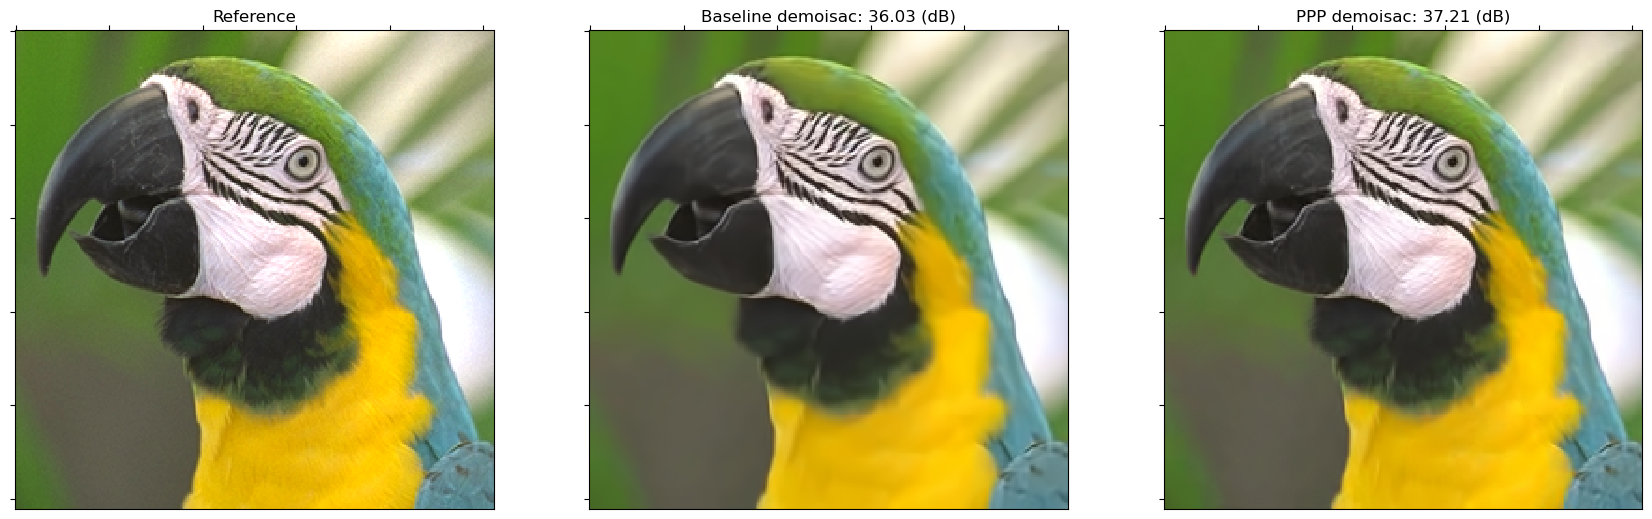

In [9]:
fig, ax = kplt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(21, 7))
kplt.imview(img, title="Reference", ax=ax[0])
kplt.imview(imgb, title="Baseline demoisac: %.2f (dB)" % metric.psnr(img, imgb), ax=ax[1])
kplt.imview(x, title="PPP demoisac: %.2f (dB)" % metric.psnr(img, x), ax=ax[2])
fig.show()

Plot convergence statistics.

/nh/research/brendt/CondaHome/miniconda3/envs/py312g/lib/python3.12/site-packages/komplot/_plot.py:150: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


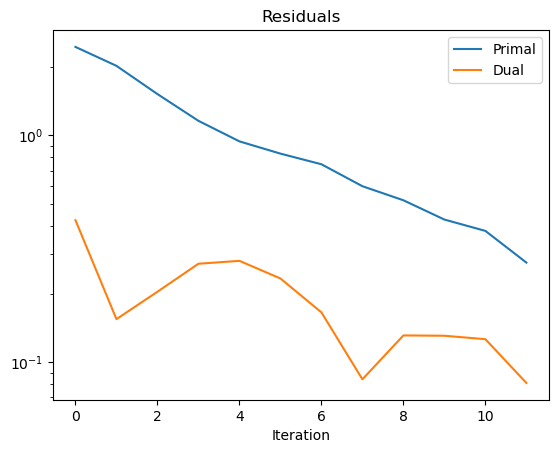

In [10]:
kplt.plot(
    snp.array((hist.Prml_Rsdl, hist.Dual_Rsdl)).T,
    ylog=True,
    title="Residuals",
    xlabel="Iteration",
    legend=("Primal", "Dual"),
)